# Inspecting Koopman Eigenvalues and Eigenvectors

This notebook trains a **GraphKoopmanModel** on the synthetic path-graph benchmark and
analyzes the learned finite-dimensional Koopman operator matrix **K**. It assumes the
encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); here the focus is what the
spectrum of **K** tells you about latent dynamics.

A **Koopman mode** is the spatial (or state-space) structure tied to one Koopman
eigenvalue: classically, if an observable is expanded in Koopman eigenfunctions
$\varphi_j$ with eigenvalues $\lambda_j$, the vector coefficients in that expansion are
the Koopman modes (Rowley et al., *J. Fluid Mech.* 2009, §2). Each mode evolves in
time by the simple factor $\lambda_j^k$.

In this notebook's finite-dimensional setting, a mode is an eigenpair
$(\lambda, v)$ of the learned matrix **K**, together with the temporal factor
$\lambda^k$ and — after decoding — the induced pattern on node features:

- **Eigenvalues** describe how each mode grows, decays, or oscillates over time.
- **Eigenvectors** describe directions in latent space that evolve simply under **K**.

**Evaluation protocol.** We train on the full synthetic sequence for spectrum analysis
(not a holdout forecasting contest). A fixed ``SEED`` makes Restart & Run All
reproducible. Spectral plots illustrate the learned operator; they are not a claim that
this unconstrained dense ``K`` is rollout-stable.


## What the spectrum tells us

In KoopmanGraph, one discrete step advances each node's latent row by the same matrix:

$$
z_{t+1} = z_t K^\top
$$

where $z_t \in \mathbb{R}^{d}$ is one node's latent vector and $K \in \mathbb{R}^{d \times d}$ is shared across nodes.

### What is a Koopman mode?

For the (infinite-dimensional) Koopman operator $U$ on observables, an eigenfunction
satisfies $U\varphi = \lambda\varphi$. Expanding a vector-valued observable $g$ in that
eigenfunction basis,

$$
g(x) = \sum_j \varphi_j(x)\, v_j,
$$

the coefficients $v_j$ are the **Koopman modes** associated with $g$; the eigenvalue
$\lambda_j$ sets that mode's growth/decay and oscillation (Rowley, Mezić, Bagheri,
Schlatter & Henningson, *J. Fluid Mech.* **641**, 115–127, 2009, eqs. (2.3)–(2.4)).
For a linear map with full-state observable, those modes reduce to ordinary
eigenvectors of the dynamics matrix.

Here we approximate that picture with a learned finite matrix **K** on latent
coordinates. We therefore call each eigenpair $(\lambda, v)$ of **K** a (discrete)
Koopman mode of the model: $v$ is the latent spatial structure, and time evolution
along that direction is multiplication by $\lambda$ each step (envelope $|\lambda|^k$).

### Eigenmodes of $K$

If $K v = \lambda v$ for a column eigenvector $v$, define the row direction $u = v^\top$. A latent state aligned with $u$ updates simply:

$$
(\alpha u) K^\top = \alpha (K v)^\top = \alpha \lambda u
$$

So one step scales that component by $\lambda$. After $k$ steps its envelope grows or decays as $|\lambda|^k$. When $\lambda$ is complex, the mode also rotates in the complex plane (usually as a conjugate pair $\lambda, \bar{\lambda}$).

### Reading eigenvalues in the complex plane

- **Inside the unit circle** ($|\lambda| < 1$): stable, decaying mode.
- **Near the unit circle** ($|\lambda| \approx 1$): slow, persistent dynamics.
- **Outside the unit circle** ($|\lambda| > 1$): growing mode; often a sign the learned operator is amplifying errors during rollout.
- **On the real axis** ($\lambda \in \mathbb{R}$): monotonic growth or decay, no oscillation within the mode.
- **Off the real axis** ($\lambda \notin \mathbb{R}$): oscillatory behavior over multiple steps.

### From spectrum to graph behavior

Eigenvectors of $K$ are directions in **lifted latent space**, not node features. The encoder chooses that space and the decoder maps back to physical variables, so a Koopman mode must be read in three layers:

1. **Spectrum** — which time scales and stabilities the operator learned.
2. **Latent directions** — which coordinates in the lifted space participate in each mode.
3. **Decoder probe** — what spatial pattern in node features a small perturbation along that direction produces.

The plots below follow that workflow on the trained model.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
)
from koopman_graph.training import LossWeights
from koopman_graph.analysis import decode_mode_shapes, plot_spectrum
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
_ = torch.manual_seed(SEED)


## Generate synthetic data

We use the same synthetic path-graph benchmark as
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb). ``SEED`` (imports cell) controls
data generation; ``torch.manual_seed`` runs immediately before module construction.


In [2]:
data_sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=20,
    num_timesteps=30,
    in_channels=3,
    topology="path",
    seed=SEED,
    initial_state="ones",
    decay_rate=0.99,
    diffusion_rate=0.1,
    noise_std=0.01,
)

print(
    f"Generated {data_sequence.num_timesteps} snapshots on "
    f"{data_sequence.num_nodes} nodes, {data_sequence.in_channels} features."
)


Generated 30 snapshots on 20 nodes, 3 features.


## Build the model

Same GCN encoder/decoder stack as the introductory tutorial, with a dense Koopman
operator. Seed weights immediately before construction for reproducibility.


In [3]:
in_channels = data_sequence.in_channels
hidden_channels = 64
latent_dim = 32
out_channels = in_channels

# Seed before constructing modules so initial weights are reproducible.
_ = torch.manual_seed(SEED)
encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
decoder = GNNDecoder(latent_dim, hidden_channels, out_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=0.1,
)


## Train

Fit with reconstruction, forward, and rollout losses so **K** is encouraged to
capture consistent multi-step latent dynamics before we inspect its spectrum.


In [4]:
loss_weights = LossWeights(reconstruction=1.0, forward=1.0, rollout=1.0)
rollout_horizon = 8
EPOCHS = 40 if os.environ.get("PYTEST_CURRENT_TEST") else 150

history = model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=rollout_horizon,
    rollout_start_seed=SEED,
)

print(f"Final training loss: {history.loss[-1]:.6f}")


Final training loss: 0.003050


## Compute the packaged Koopman spectrum

``model.spectrum()`` diagonalizes **K**, sorts modes by decreasing magnitude, and uses
``model.time_step`` to convert discrete eigenvalues into continuous-time growth rates
and frequencies. Growth rates are $\log|\lambda| / \Delta t$; frequencies are
$\arg(\lambda) / (2\pi\,\Delta t)$ in **cycles per unit time**. Column eigenvectors
satisfy $K v = \lambda v$.

For continuous-time generators see ``12_irregular_sampling_continuous_time.ipynb`` and
``20_continuous_spectrum_auxiliary_network.ipynb``. For ``koopman="graph"``, pass the
same ``edge_index`` / ``num_nodes`` used in propagation into ``model.spectrum(...)``.


In [5]:
model.eval()
spectrum = model.spectrum()
# ``.matrix`` is the operator contract; for dense discrete K it equals ``.K``.
# ``spectrum`` eigenpairs are already sorted by descending |λ|.
K = model.koopman.matrix.detach().cpu()
eigvals = spectrum.eigenvalues.detach().cpu()
eigvecs = spectrum.eigenvectors.detach().cpu()
magnitudes = spectrum.magnitudes.detach().cpu()
growth_rates = spectrum.growth_rates.detach().cpu()
frequencies = spectrum.frequencies.detach().cpu()

lead_mag = float(magnitudes[0])
print(f"K shape: {tuple(K.shape)}")
print(f"Top-5 |lambda|: {magnitudes[:5].tolist()}")
print(f"Top-5 growth rates: {growth_rates[:5].tolist()}")
print(f"Top-5 frequencies (cycles / unit time): {frequencies[:5].tolist()}")
print(
    f"Leading |lambda|^{rollout_horizon} (train horizon): {lead_mag ** rollout_horizon:.3f}"
)
print(f"Leading |lambda|^20: {lead_mag ** 20:.3f}")


K shape: (32, 32)
Top-5 |lambda|: [1.0510131120681763, 1.0432173013687134, 1.0432173013687134, 1.0359500646591187, 1.033953309059143]
Top-5 growth rates: [0.49754565954208374, 0.4230949580669403, 0.4230949580669403, 0.3531894087791443, 0.3338961899280548]
Top-5 frequencies (cycles / unit time): [0.0, -0.023154539987444878, 0.023154539987444878, 0.0, -0.04541356489062309]
Leading |lambda|^8 (train horizon): 1.489
Leading |lambda|^20: 2.705


## Plot the eigenvalue spectrum

The unit circle marks the stability boundary for discrete-time linear dynamics. Modes
inside the circle decay; modes outside grow. We plot with ``limits="data"`` so axes
zoom to the eigenvalue cloud (still drawing the unit circle for reference) instead of
a fixed full-disk frame that can hide local structure near $|\lambda| \approx 1$.

The printout above reports this run's leading $|\lambda|$ and the amplification
$|\lambda|^k$ at the training rollout horizon and at $k=20$. Mild instability
(leading modes slightly outside the unit circle) is common when training an
unconstrained operator on short, decaying trajectories: even a few percent above
1 compounds over the trained horizon, and longer rollouts amplify errors further.
See `08_loss_stability.ipynb` for spectral parameterizations and eigenvalue
penalties that keep $|\lambda| \le 1$.


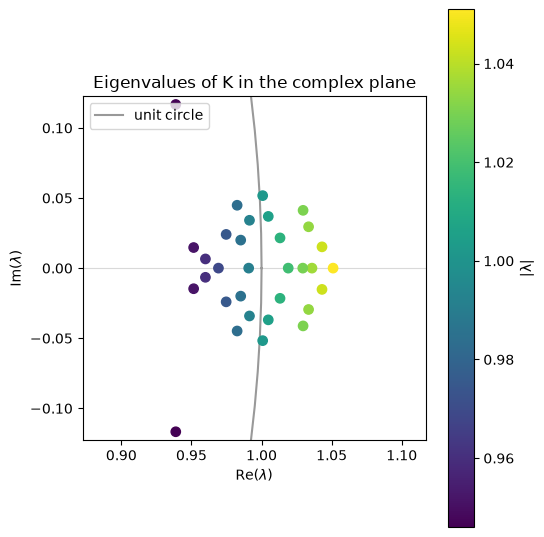

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

scatter = plot_spectrum(spectrum, ax=ax, limits="data")
ax.set_title("Eigenvalues of K in the complex plane")
ax.legend(loc="upper left")
fig.colorbar(scatter, ax=ax, label="|λ|")
fig.tight_layout()
plt.show()


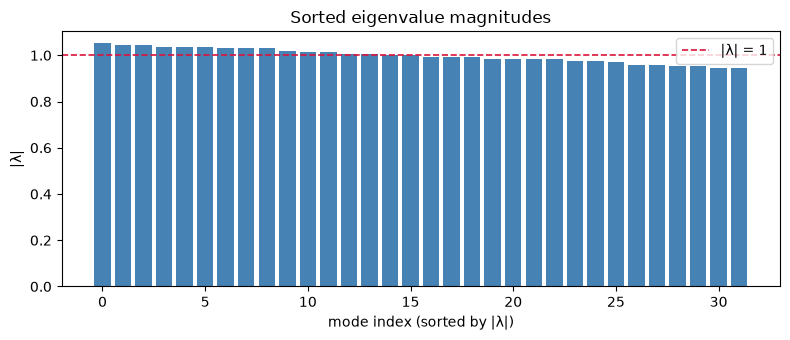

In [7]:
sorted_mags = magnitudes.numpy()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(np.arange(len(sorted_mags)), sorted_mags, color="steelblue")
ax.axhline(1.0, color="crimson", linestyle="--", linewidth=1.2, label="|λ| = 1")
ax.set_xlabel("mode index (sorted by |λ|)")
ax.set_ylabel("|λ|")
ax.set_title("Sorted eigenvalue magnitudes")
ax.legend()
fig.tight_layout()
plt.show()

## Inspect the operator matrix and leading eigenvectors

The heatmap of **K** shows cross-coupling between latent coordinates. Leading eigenvectors
highlight the dominant latent directions. Complex conjugate pairs are common for real
**K**; we therefore show both the real part and the magnitude $|v|$ so oscillatory
modes are not reduced to a single real slice.

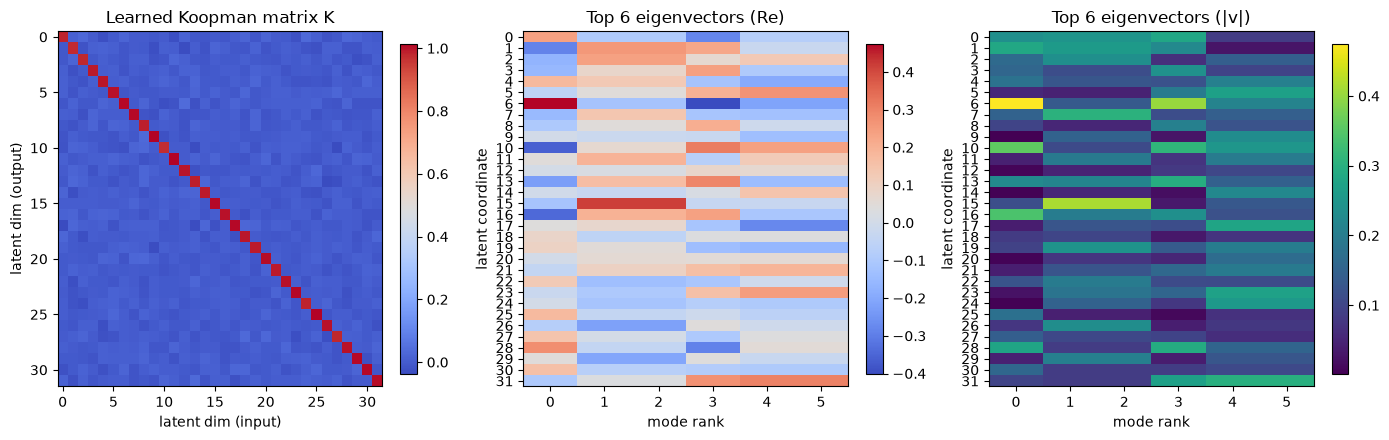

In [8]:
top_k = 6
top_vecs = eigvecs[:, :top_k]
top_re = top_vecs.real.numpy()
top_abs = top_vecs.abs().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

im0 = axes[0].imshow(K.numpy(), aspect="auto", cmap="coolwarm")
axes[0].set_title("Learned Koopman matrix K")
axes[0].set_xlabel("latent dim (input)")
axes[0].set_ylabel("latent dim (output)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(top_re, aspect="auto", cmap="coolwarm")
axes[1].set_title(f"Top {top_k} eigenvectors (Re)")
axes[1].set_xlabel("mode rank")
axes[1].set_yticks(range(latent_dim))
axes[1].set_ylabel("latent coordinate")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(top_abs, aspect="auto", cmap="viridis")
axes[2].set_title(f"Top {top_k} eigenvectors (|v|)")
axes[2].set_xlabel("mode rank")
axes[2].set_yticks(range(latent_dim))
axes[2].set_ylabel("latent coordinate")
fig.colorbar(im2, ax=axes[2], fraction=0.046)

fig.tight_layout()
plt.show()

## Mode time evolution: $|\lambda|^k$

For a mode with eigenvalue $\lambda$, one-step Koopman evolution scales its amplitude
by $|\lambda|$. Complex eigenvalues add oscillation through the phase of $\lambda^k$.
We plot a few leading (largest-magnitude) modes together with the most decaying mode
so growth and decay are both visible.


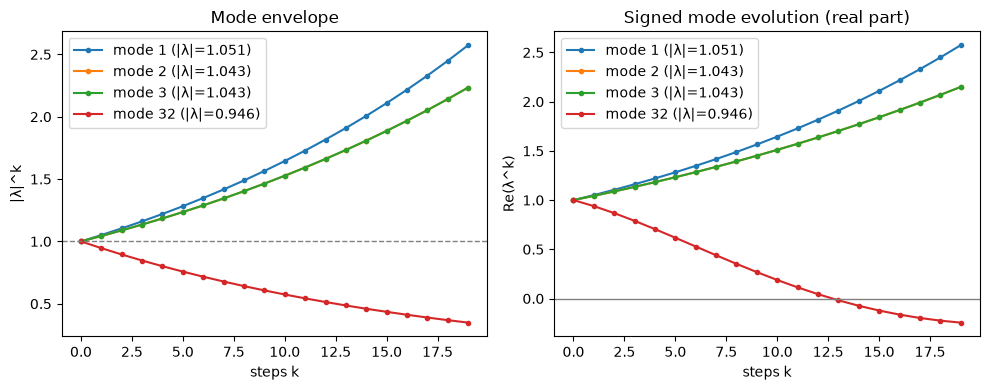

In [9]:
horizon = 20
steps = np.arange(horizon)
leading_ranks = [0, 1, 2]
below_one = (magnitudes < 1.0).nonzero(as_tuple=True)[0]
decaying_rank = (
    int(below_one[-1].item())
    if below_one.numel()
    else int(torch.argmin(magnitudes).item())
)
mode_ranks = leading_ranks + [decaying_rank]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for rank in mode_ranks:
    lam = eigvals[rank]
    mag = float(lam.abs())
    envelope = mag ** steps
    axes[0].plot(
        steps,
        envelope,
        marker="o",
        markersize=3,
        label=f"mode {rank + 1} (|λ|={mag:.3f})",
    )

axes[0].axhline(1.0, color="0.5", linestyle="--", linewidth=1)
axes[0].set_xlabel("steps k")
axes[0].set_ylabel("|λ|^k")
axes[0].set_title("Mode envelope")
axes[0].legend()

for rank in mode_ranks:
    lam = eigvals[rank]
    mag = float(lam.abs())
    signal = (lam.numpy() ** steps).real
    axes[1].plot(
        steps,
        signal,
        marker="o",
        markersize=3,
        label=f"mode {rank + 1} (|λ|={mag:.3f})",
    )

axes[1].axhline(0.0, color="0.5", linewidth=1)
axes[1].set_xlabel("steps k")
axes[1].set_ylabel("Re(λ^k)")
axes[1].set_title("Signed mode evolution (real part)")
axes[1].legend()

fig.tight_layout()
plt.show()


## From latent modes to spatial patterns

To connect a latent eigenvector to physical node features, we apply a small perturbation
along the eigenvector to encoded states and decode the difference. This finite-difference
probe approximates how the decoder responds to that Koopman mode direction. Absolute
sensitivities can share a large common offset from the nonlinear decoder, so we demean
each mode across nodes to highlight spatial structure.

Conjugate eigenvalue pairs share the same real decode response on a real feature channel,
so plotting Re for both partners overlays. We therefore show Re for the leading real mode
and one conjugate partner, plus Im for that partner to expose the oscillatory spatial
structure.

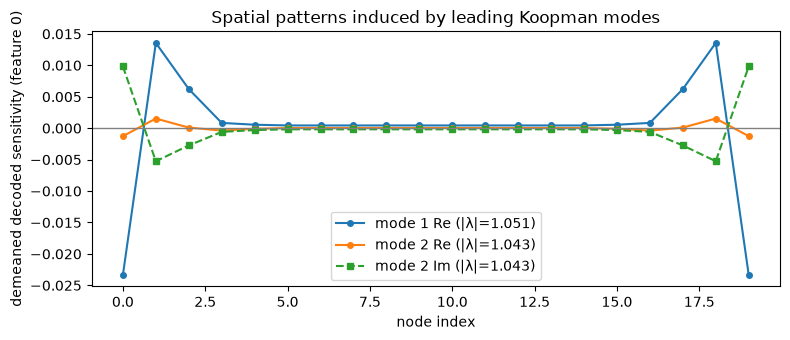

In [10]:
initial_graph = data_sequence[0]
alpha = 0.05
# Leading real mode (0) + one member of the first conjugate pair (1).
mode_ranks = [0, 1]
feature_idx = 0

mode_shapes = decode_mode_shapes(
    model,
    initial_graph,
    mode_indices=mode_ranks,
    perturbation=alpha,
)

nodes = np.arange(data_sequence.num_nodes)
fig, ax = plt.subplots(figsize=(8, 3.5))


def _demeaned(values):
    centered = values - values.mean()
    return centered.cpu().numpy()


for i, mode_rank in enumerate(mode_ranks):
    mag = float(magnitudes[mode_rank])
    ax.plot(
        nodes,
        _demeaned(mode_shapes[i].real[:, feature_idx]),
        marker="o",
        markersize=4,
        label=f"mode {mode_rank + 1} Re (|λ|={mag:.3f})",
    )

# Imaginary decode part for the conjugate partner (mode 2 would overlay on Re).
conj_i = 1
mag = float(magnitudes[mode_ranks[conj_i]])
ax.plot(
    nodes,
    _demeaned(mode_shapes[conj_i].imag[:, feature_idx]),
    marker="s",
    markersize=4,
    linestyle="--",
    label=f"mode {mode_ranks[conj_i] + 1} Im (|λ|={mag:.3f})",
)

ax.axhline(0.0, color="0.5", linewidth=1)
ax.set_xlabel("node index")
ax.set_ylabel(f"demeaned decoded sensitivity (feature {feature_idx})")
ax.set_title("Spatial patterns induced by leading Koopman modes")
ax.legend()
fig.tight_layout()
plt.show()


## Verify the finite-matrix eigenpair identity

This check is linear algebra on the learned matrix: for each eigenpair
$(\lambda, v)$ we expect $K v \approx \lambda v$. Small residuals indicate that
**K** is well approximated by its spectral decomposition — not that these are
exact eigenfunctions of the infinite-dimensional Koopman operator on the
underlying nonlinear dynamics.

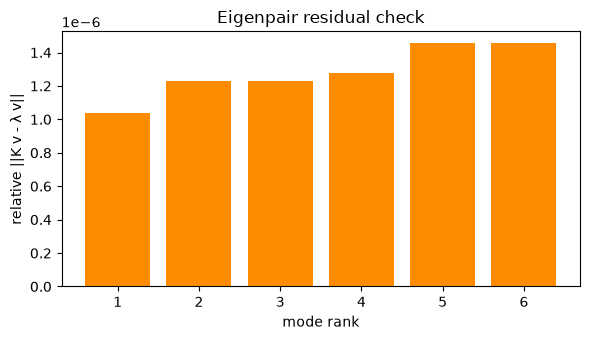

Relative residuals for top modes: ['1.04e-06', '1.23e-06', '1.23e-06', '1.28e-06', '1.45e-06', '1.45e-06']


In [11]:
residuals = []
K_complex = K.to(torch.complex64)
for idx in range(top_k):
    v = eigvecs[:, idx]
    lhs = K_complex @ v
    rhs = eigvals[idx] * v
    rel_err = (lhs - rhs).norm() / (rhs.norm() + 1e-12)
    residuals.append(rel_err.item())

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(np.arange(1, top_k + 1), residuals, color="darkorange")
ax.set_xlabel("mode rank")
ax.set_ylabel("relative ||K v - λ v||")
ax.set_title("Eigenpair residual check")
fig.tight_layout()
plt.show()

print("Relative residuals for top modes:", [f"{r:.2e}" for r in residuals])

## Takeaways

- **Spectrum summary:** The eigenvalue spectrum summarizes stability and time-scale
  structure of learned latent dynamics; eigenvectors are coordinates in the lifted
  space — decode probes help relate them to graph features.
- **What this run shows:** Dominant modes with $|\lambda| \approx 1$ often carry
  persistent dynamics, while $|\lambda| < 1$ modes decay. This model's leading modes
  land slightly *above* 1 — that already compounds over the trained horizon (see the
  printed $|\lambda|^{\mathrm{horizon}}$) and is a stronger warning for long rollouts.
- **What this does *not* show:** A claim that unconstrained dense ``K`` is
  rollout-stable. Constrain the spectrum when stability matters (see
  [`08_loss_stability.ipynb`](08_loss_stability.ipynb) and
  [`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb)).
- **Figures:** Spectrum, mode envelopes, and spatial decode panels illustrate the
  learned operator for this seed; they are qualitative diagnostics, not a forecasting
  leaderboard.

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the full train/predict workflow.
- See [`08_loss_stability.ipynb`](08_loss_stability.ipynb) and
  [`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb) for spectral constraints.
- For continuous-time / generator spectra see
  [`12_irregular_sampling_continuous_time.ipynb`](12_irregular_sampling_continuous_time.ipynb)
  and [`20_continuous_spectrum_auxiliary_network.ipynb`](20_continuous_spectrum_auxiliary_network.ipynb).
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
